# Notebook to analyze issues with common features across datasets

In [1]:
import pathlib

import pandas as pd
import numpy as np

In [2]:
data_folder = pathlib.Path("../data/")
processed_data_folder = data_folder / "processed"
raw_data_folder = data_folder / "raw"
interim_data_folder = data_folder / "interim"

In [3]:
FEATURE_REP = "kofam"
DATASETS = ["atleaf", "lit", "pmi"]

## Phenotype data preparation

In [4]:
phenotype_data_folder = processed_data_folder / "phenotypes"
atleaf_phenotype_names = set(f.stem for f in (phenotype_data_folder / "atleaf").glob("*.tsv"))
lit_phenotype_names = set(f.stem for f in (phenotype_data_folder / "lit").glob("*.tsv"))
pmi_phenotype_names = set(f.stem for f in (phenotype_data_folder / "pmi").glob("*.tsv"))
common_phenotype_names = sorted(set.intersection(atleaf_phenotype_names, lit_phenotype_names, pmi_phenotype_names))
len(common_phenotype_names)

16

In [5]:
phenotype_data = {}
for dataset in DATASETS:
    phenotype_data[dataset] = {}
    for phenotype_name in common_phenotype_names:
        phenotype_data[dataset][phenotype_name] = pd.read_csv(
            phenotype_data_folder / dataset / f"{phenotype_name}.tsv",
            sep="\t",
            index_col=0,
            dtype={"genomeID": str},
        ).dropna().astype(np.int8)
        s = phenotype_data[dataset][phenotype_name].iloc[:, 0]
        if s.nunique() > 2:
            raise ValueError(f"Phenotype {phenotype_name} in dataset {dataset} has more than 2 labels")

## Get phenotype relevant genes from KEGG

### Get KO from KO mappings

In [6]:
import json

In [7]:
annotation_file = pathlib.Path("../data/external/mapping/KO_dictionary.json")
with open(annotation_file) as f:
    raw_data = json.load(f)
    ko_dict = {k.removeprefix("KO:"): v["name"] for k, v in raw_data["term_hash"].items()}

In [8]:
def get_relevant_genes(feature_matrix, ko_dict, keyword):
    f_ids = feature_matrix.columns
    f_annots = [ko_dict.get(k, "missing") for k in f_ids]
    relevant_genes = [k for k, v in zip(f_ids, f_annots) if keyword in v.lower()]
    return relevant_genes

### Get module -> KO mapping

In [9]:
module_mapping_file = pathlib.Path("../data/external/mapping/module-definitions.tsv")
module_mapping_df = pd.read_csv(module_mapping_file, sep="\t", index_col=0)
ko_list = module_mapping_df["Definition"].str.replace(" ", ",").str.replace("+", ",").str.replace("(", "").str.replace(")", "").str.replace("-", "").str.split(",")
module_mapping = dict(zip(module_mapping_df.index, ko_list))

### Get KO from KEGG API and modules file

In [10]:
import requests

In [11]:
def get_pathways_for_keyword(keyword):
    search_url = f"http://rest.kegg.jp/find/pathway/{keyword}"
    response = requests.get(search_url)
    pathways = response.text.strip().split('\n')
    return [line.split('\t')[0] for line in pathways]

def get_modules_for_keyword(keyword):
    search_url = f"http://rest.kegg.jp/find/module/{keyword}"
    response = requests.get(search_url)
    modules = response.text.strip().split('\n')
    return [line.split('\t')[0] for line in modules]

def get_orthologs_for_keyword(keyword):
    search_url = f"http://rest.kegg.jp/find/orthology/{keyword}"
    response = requests.get(search_url)
    orthologs = response.text.strip().split('\n')
    return [line.split('\t')[0] for line in orthologs]

def get_modules_for_pathway(pathway_id):
    # Retrieve pathway details to get modules
    get_url = f"http://rest.kegg.jp/get/{pathway_id}"
    response = requests.get(get_url)
    lines = [l.strip() for l in response.text.strip().split('\n')]
    modules = []
    for line in lines:
        if line.startswith("MODULE"):
            modules.append(line.split()[1])
        elif line.startswith("M"):
            modules.append(line.split()[0])
    return modules

def get_orthologs(keyword, module_mapping):
    orthologs = set()
    # Step1: Get orthologs from pathway
    pathways = get_pathways_for_keyword(keyword)
    for pathway_id in pathways:
        modules = get_modules_for_pathway(pathway_id)
        for raw_module_id in modules:
            module_id = raw_module_id.split(":")[-1]
            orthologs.update(module_mapping.get(module_id, []))
    # Step2: Get orthologs from modules
    for raw_module_id in get_modules_for_keyword(keyword):
        module_id = raw_module_id.split(":")[-1]
        orthologs.update(module_mapping.get(module_id, []))
    # Step3: Get orthologs from keyword
    for raw_ortholog_id in get_orthologs_for_keyword(keyword):
        ortholog_id = raw_ortholog_id.split(":")[-1]
        orthologs.add(ortholog_id)
    return sorted(orthologs)

In [12]:
keyword_map = {
 'Alanine': "alanine",
 'Arginine': "arginine",
 'Cellobiose': "cellob",
 'Fructose': "fruct",
 'Galactose': "galac",
 'Galacturonic-Acid': "galactu",
 'Glucose': "glucose",
 'Glycerol': "glycerol",
 'Histidine': "histidine",
 'Maltose': "malt",
 'Mannitol': "mann",
 'Mannose': "mann",
 'Serine': "serine",
 'Sucrose': "sucr",
 'Trehalose': "trehal",
 'm-Inositol': "inositol"
}

In [13]:
relevant_orthologs = {}
for phenotype_name in common_phenotype_names:
    keyword = keyword_map[phenotype_name]
    relevant_orthologs[phenotype_name] = get_orthologs(keyword, module_mapping)

In [14]:
{k: len(v) for k, v in relevant_orthologs.items()}

{'Alanine': 159,
 'Arginine': 158,
 'Cellobiose': 16,
 'Fructose': 115,
 'Galactose': 301,
 'Galacturonic-Acid': 51,
 'Glucose': 193,
 'Glycerol': 153,
 'Histidine': 176,
 'Maltose': 40,
 'Mannitol': 238,
 'Mannose': 238,
 'Serine': 455,
 'Sucrose': 42,
 'Trehalose': 40,
 'm-Inositol': 132}

## Feature data preparation

In [15]:
feature_raw_data_folder = raw_data_folder / "features/biolog"
phenotype_raw_data_folder = raw_data_folder / "phenotypes"
feature_full_data_folder = interim_data_folder / "features"
feature_nocorr_data_folder = processed_data_folder / "features_reduced"

### Create interim feature data (if needed)

In [16]:
def read_raw_feature_data(feature_file: pathlib.Path, feature_type: str) -> pd.DataFrame:
    if feature_type == "kofam_modules":
        dtype = np.float64
    else:
        dtype = np.int8
    raw_data = pd.read_csv(feature_file, sep="\t", index_col=0).dropna().astype(dtype)
    index_format_func=lambda x: x.strip().split("?")[-1].removesuffix(".RAST").removesuffix(".fna").removeprefix("g")
    raw_data.index = raw_data.index.map(index_format_func)
    raw_data.index.name = "genomeID"
    return raw_data

In [17]:
def read_raw_phenotype_data(phenotype_file: pathlib.Path) -> pd.DataFrame:
    index_format_func=lambda x: x.strip().split("?")[-1].removesuffix(".RAST").removesuffix(".fna").removeprefix("g")
    raw_data = pd.read_csv(phenotype_file, sep="\t", index_col=0)
    raw_data.index = raw_data.index.map(index_format_func)
    raw_data.index.name = "genomeID"
    return raw_data

### Create features_full, features_nocorr, features_sel datasets

In [18]:
features_full = {}
feature_raw_data_file = feature_raw_data_folder / f"{FEATURE_REP}.tsv"
feature_raw_data = read_raw_feature_data(feature_raw_data_file, FEATURE_REP)
for dataset in DATASETS:
    feature_full_data_file = feature_full_data_folder / f"{dataset}/{FEATURE_REP}.tsv"
    if not feature_full_data_file.is_file():
        folder = feature_full_data_file.parent
        folder.mkdir(parents=True)
        phenotype_raw_data_file = phenotype_raw_data_folder / f"{dataset}_phenotypes.tsv"
        phenotype_raw_data = read_raw_phenotype_data(phenotype_raw_data_file)
        common_index = feature_raw_data.index.intersection(phenotype_raw_data.index)
        features_full[dataset] = feature_raw_data.loc[common_index]
        features_full[dataset].to_csv(feature_full_data_file, sep="\t", index=True)
    else:
        features_full[dataset] = pd.read_csv(feature_full_data_file, sep="\t", index_col=0, dtype={"genomeID": str}).astype(np.int8)

In [19]:
features_nocorr = {}
for dataset in DATASETS:
    feature_file = feature_nocorr_data_folder / f"{dataset}/{FEATURE_REP}/{FEATURE_REP}.tsv"
    features_nocorr[dataset] = pd.read_csv(feature_file, sep="\t", index_col=0, dtype={"genomeID": str}).astype(np.int8)

In [20]:
features_sel = {}
for dataset in DATASETS:
    features_sel[dataset] = {}
    for phenotype_name in common_phenotype_names:
        common_cols = features_full[dataset].columns.intersection(relevant_orthologs[phenotype_name])
        features_sel[dataset][phenotype_name] = features_full[dataset][common_cols]

In [21]:
# Display the samples and features in the two datasets
features_full["atleaf"].shape, features_full["lit"].shape, features_nocorr["atleaf"].shape, features_nocorr["lit"].shape

((492, 6863), (362, 6863), (206, 3925), (362, 5345))

In [22]:
# Number of common features in the two datasets
intersection = len(set(features_nocorr[DATASETS[0]].columns) & set(features_nocorr[DATASETS[1]].columns))
union = len(set(features_nocorr[DATASETS[0]].columns) | set(features_nocorr[DATASETS[1]].columns))
print(f"{intersection / union * 100:.2f}% of features are in common between the two datasets")

65.30% of features are in common between the two datasets


In [23]:
features_sel["atleaf"]["Galactose"].shape, features_sel["lit"]["Galactose"].shape

((492, 97), (362, 97))

## Create training data

In [24]:
from collections import defaultdict

from sklearn.model_selection import train_test_split

In [25]:
# type(full, nocorr, sel) -> dataset -> phenotype
ftypes = ["full", "nocorr", "sel"]
data_split = {}
data_full = {}
for ftype in ftypes:
    for dataset in DATASETS:
        for phenotype_name in common_phenotype_names:
            if ftype == "full":
                X_raw = features_full[dataset].copy()
            elif ftype == "nocorr":
                X_raw = features_nocorr[dataset].copy()
            elif ftype == "sel":
                X_raw = features_sel[dataset][phenotype_name].copy()
            else:
                raise ValueError(f"Unknown feature type: {ftype}")
            X_raw = X_raw[~X_raw.index.duplicated(keep='first')].astype(np.int8)
            y_raw = phenotype_data[dataset][phenotype_name].dropna().astype(np.int8)
            y_raw = y_raw[~y_raw.index.duplicated(keep='first')]
            common_index = X_raw.index.intersection(y_raw.index)
            X = X_raw.loc[common_index]
            # NOTE: Enforce bool features
            if FEATURE_REP != "kofam_modules":
                X[X > 0] = 1
            y = y_raw.loc[common_index, phenotype_name]
            data_full[(ftype, dataset, phenotype_name)] = {
                "X": X,
                "y": y,
            }
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
            data_split[(ftype, dataset, phenotype_name)] = {
                "X_train": X_train,
                "X_test": X_test,
                "y_train": y_train,
                "y_test": y_test,
            }

## Machine learning

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, matthews_corrcoef, balanced_accuracy_score
from catboost import CatBoostClassifier, Pool

In [27]:
N_FEATURES = 25
SCORING = ["accuracy", "balanced_accuracy", "matthews_corrcoef"]
CTYPE = "RandomForestClassifier"
# CTYPE = "CatBoostClassifier"

In [28]:
def make_classifier(ctype="RandomForestClassifier"):
    if ctype == "CatBoostClassifier":
        clf = CatBoostClassifier(
            random_state=42,
            objective="Logloss",
            verbose=False,
            allow_writing_files=False,
            thread_count=-1,
            task_type="CPU",
            eval_metric="MCC", # "LogLoss", "MCC", "BalancedAccuracy"
            # od_type="IncToDec",
            # od_wait=20,
        )
    elif ctype == "RandomForestClassifier":
        clf = RandomForestClassifier(n_estimators=1_000, random_state=42)
    else:
        raise ValueError("Invalid classifier type")
    return clf

In [29]:
def get_feature_importance(clf, X, y, ctype="RandomForestClassifier"):
    if ctype == "CatBoostClassifier":
        feature_importances = clf.get_feature_importance(Pool(X, label=y))
    elif ctype == "RandomForestClassifier":
        feature_importances = clf.feature_importances_
    else:
        raise ValueError("Invalid classifier type")
    feature_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': feature_importances,
    })
    sorted_feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
    return sorted_feature_importance_df

### Determine the number of common features across CV folds

In [30]:
from sklearn.model_selection import cross_validate, StratifiedKFold

In [31]:
def perform_cv(clf, X, y, scoring, n_features):
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_results = cross_validate(clf, X, y, scoring=scoring, cv=kfold, n_jobs=-1, return_estimator=True, return_indices=True)
    cols = [f"test_{metric}" for metric in scoring]
    cv_test_scores = {metric: cv_results[metric] for metric in cols}
    score_df = pd.DataFrame(cv_test_scores)
    score_df.columns = [metric.replace("test_", "") for metric in cols]
    feature_importances = []
    fold = 1
    for estimator, train_indices in zip(cv_results["estimator"], cv_results["indices"]["train"]):
        importance_df = get_feature_importance(estimator, X.iloc[train_indices], y.iloc[train_indices]).head(n_features)
        importance_df["fold"] = fold
        fold += 1
        feature_importances.append(importance_df)
    feature_importances_df = pd.concat(feature_importances)
    return score_df, feature_importances_df

In [32]:
feature_importances_cv = []
cv_scores = []
for i, (ftype, dataset, phenotype_name) in enumerate(data_full):
    if dataset == "pmi":
        continue
    print(f"Processing {i+1}/{len(data_full)}: {ftype}, {dataset}, {phenotype_name}")
    X = data_full[(ftype, dataset, phenotype_name)]["X"]
    nrows, ncols = X.shape
    if nrows < 50 or ncols < 5:
        print(f"Skipping {ftype}, {dataset}, {phenotype_name} due to low data")
        continue
    y = data_full[(ftype, dataset, phenotype_name)]["y"]
    clf = make_classifier(CTYPE)
    score_df, importance_df  = perform_cv(clf, X, y, SCORING, N_FEATURES)
    score_df["ftype"] = ftype
    score_df["dataset"] = dataset
    score_df["phenotype"] = phenotype_name
    cv_scores.append(score_df)
    importance_df["ftype"] = ftype
    importance_df["dataset"] = dataset
    importance_df["phenotype"] = phenotype_name
    feature_importances_cv.append(importance_df)
feature_importances_cv_df = pd.concat(feature_importances_cv)
cv_scores_df = pd.concat(cv_scores)

Processing 1/144: full, atleaf, Alanine
Processing 2/144: full, atleaf, Arginine
Processing 3/144: full, atleaf, Cellobiose
Processing 4/144: full, atleaf, Fructose
Processing 5/144: full, atleaf, Galactose
Processing 6/144: full, atleaf, Galacturonic-Acid
Processing 7/144: full, atleaf, Glucose
Processing 8/144: full, atleaf, Glycerol
Processing 9/144: full, atleaf, Histidine
Processing 10/144: full, atleaf, Maltose
Processing 11/144: full, atleaf, Mannitol
Processing 12/144: full, atleaf, Mannose
Processing 13/144: full, atleaf, Serine
Processing 14/144: full, atleaf, Sucrose
Processing 15/144: full, atleaf, Trehalose
Processing 16/144: full, atleaf, m-Inositol
Processing 17/144: full, lit, Alanine
Processing 18/144: full, lit, Arginine
Processing 19/144: full, lit, Cellobiose
Processing 20/144: full, lit, Fructose
Processing 21/144: full, lit, Galactose
Processing 22/144: full, lit, Galacturonic-Acid
Processing 23/144: full, lit, Glucose
Processing 24/144: full, lit, Glycerol
Proces

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


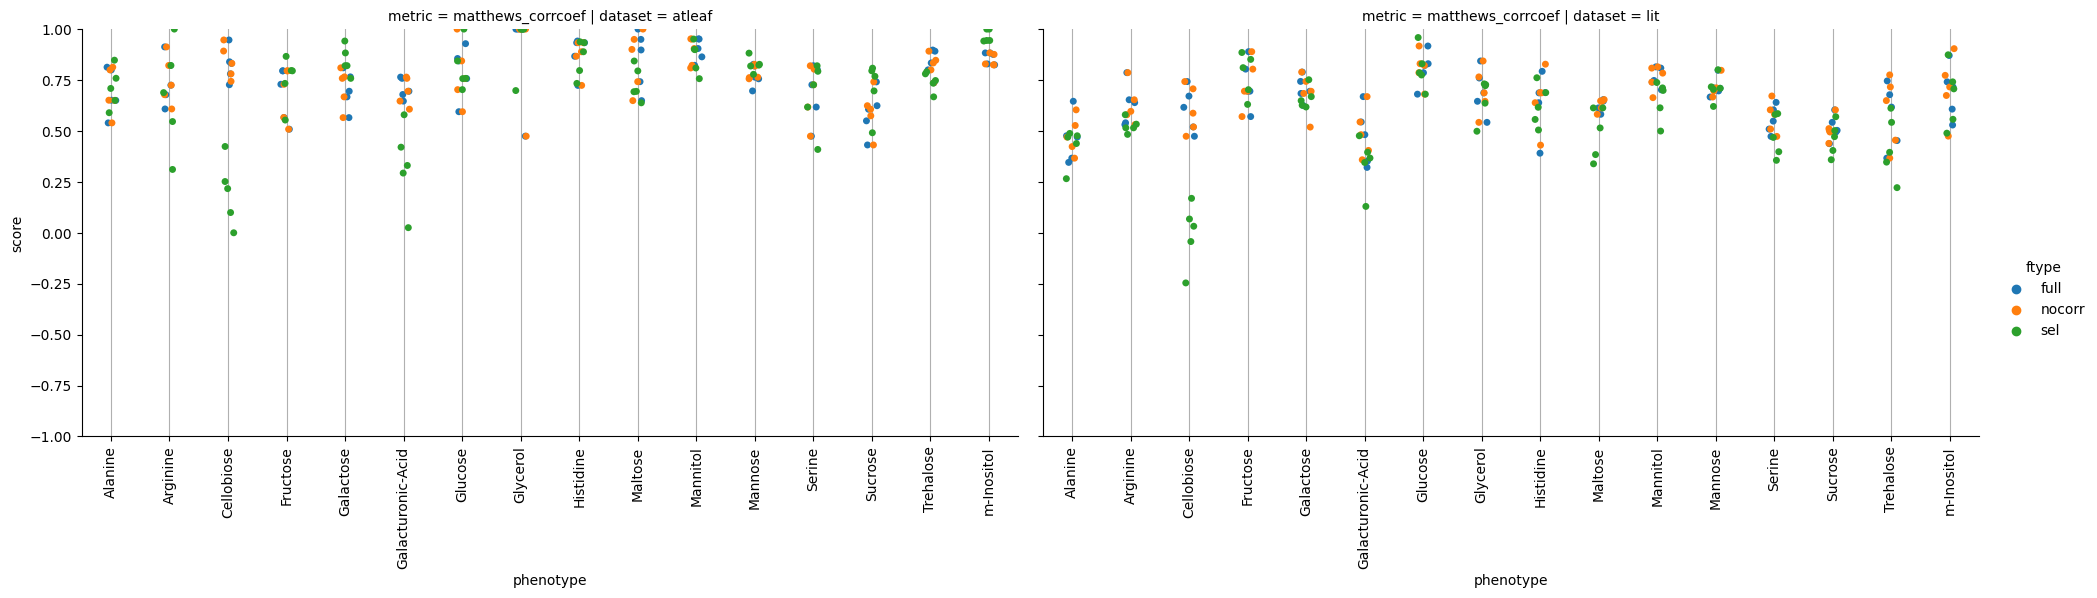

In [34]:
plot_data = cv_scores_df.melt(id_vars=["ftype", "dataset", "phenotype"], var_name="metric", value_name="score")
plot_data = plot_data[(plot_data["metric"] == "matthews_corrcoef")]
g = sns.catplot(data=plot_data, x="phenotype", y="score", hue="ftype", kind="strip", row="metric", col="dataset", height=5, aspect=2)
for ax in g.axes.flat:
    ax.set_ylim(-1, 1)
    ax.grid(True, axis="x")
    for label in ax.get_xticklabels():
        label.set_rotation(90)

/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


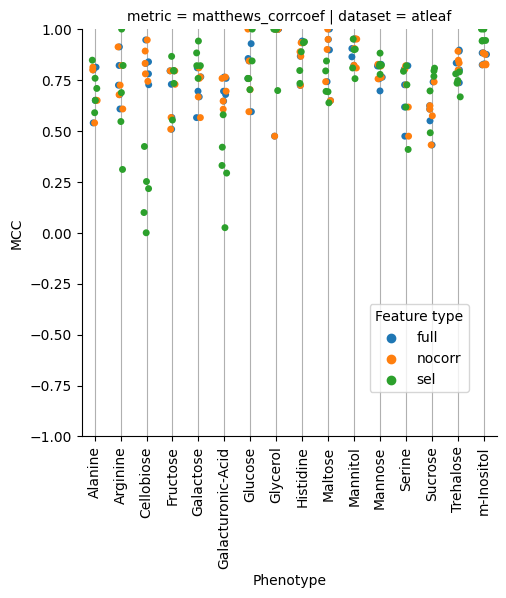

In [35]:
plot_data = cv_scores_df.melt(id_vars=["ftype", "dataset", "phenotype"], var_name="metric", value_name="score")
plot_data = plot_data[(plot_data["metric"] == "matthews_corrcoef") & (plot_data["dataset"] == "atleaf")]
g = sns.catplot(data=plot_data, x="phenotype", y="score", hue="ftype", kind="strip", row="metric", col="dataset")
for ax in g.axes.flat:
    ax.set_ylim(-1, 1)
    ax.grid(True, axis="x")
    for label in ax.get_xticklabels():
        label.set_rotation(90)
plt.ylabel("MCC");
plt.xlabel("Phenotype");
g._legend.set_title("Feature type");
g._legend.set_bbox_to_anchor((0.8, 0.5))  # Center the legend at the bottom
g._legend.set_frame_on(True)

In [36]:
def get_num_common_features(grp_df):
    n_folds = grp_df["fold"].max()
    common_bool = grp_df["Feature"].value_counts() == n_folds
    common_elem = set(common_bool[common_bool].index)
    n_common = len(common_elem)
    return n_common

In [37]:
numcommon_features_cv = feature_importances_cv_df.groupby(["ftype", "dataset", "phenotype"]).apply(get_num_common_features).reset_index(name="n_common_features")

/tmp/ipykernel_4025751/3205686308.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  numcommon_features_cv = feature_importances_cv_df.groupby(["ftype", "dataset", "phenotype"]).apply(get_num_common_features).reset_index(name="n_common_features")


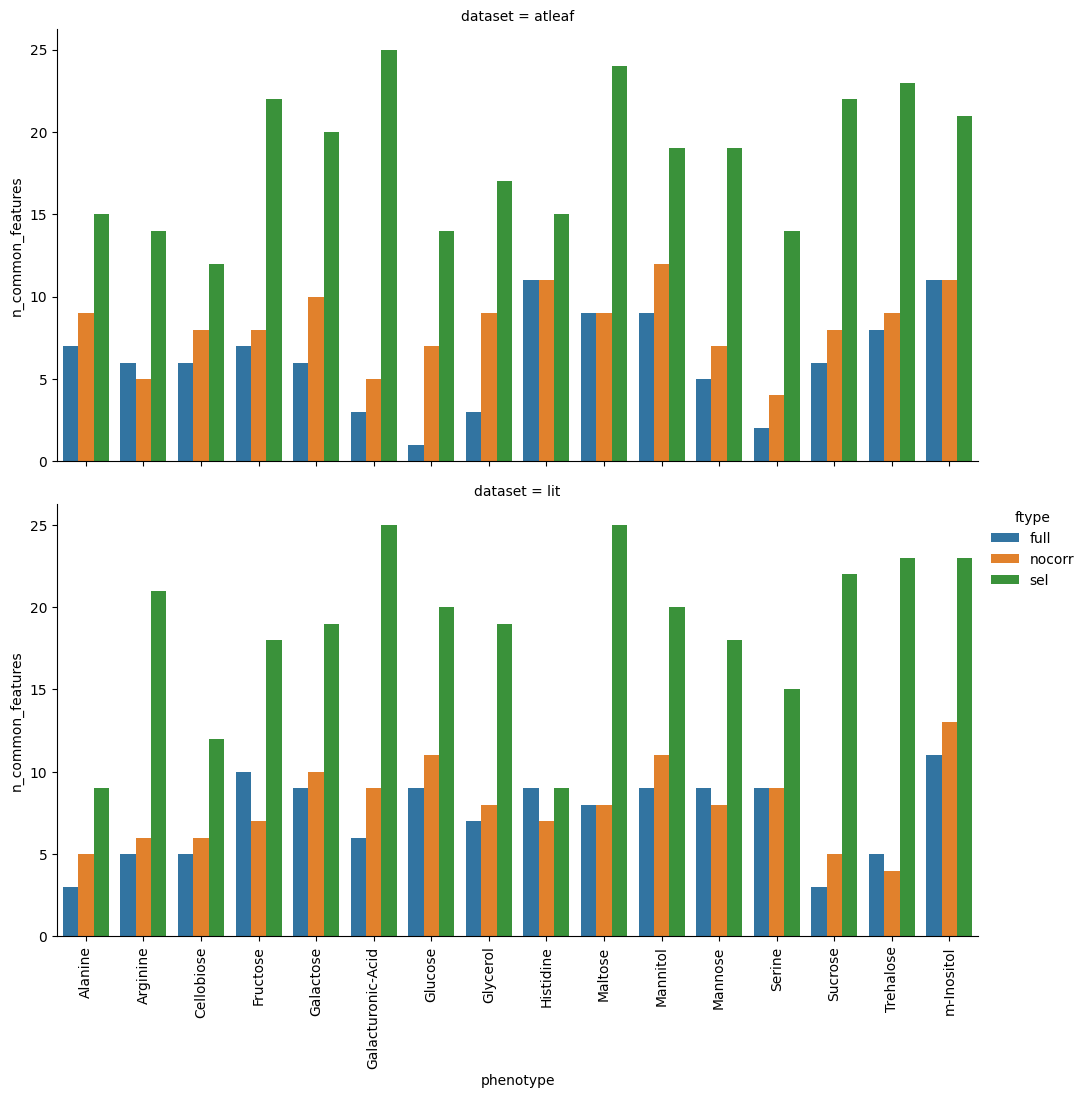

In [38]:
sns.catplot(data=numcommon_features_cv, x="phenotype", y="n_common_features", hue="ftype", kind="bar", row="dataset", height=5, aspect=2)
plt.xticks(rotation=90);

### Determine the number of common features across datasets

In [39]:
def get_common_features(grp_df):
    n_folds = grp_df["fold"].max()
    common_bool = grp_df["Feature"].value_counts() == n_folds
    common_elem = set(common_bool[common_bool].index)
    return common_elem

def get_feature_intersection(grp_df):
    common_features = grp_df["common_features"]
    if len(common_features) > 2:
        raise ValueError("More than 2 common feature sets")
    for i, features in enumerate(common_features):
        if i == 0:
            common_set = set(features)
        else:
            common_set = common_set.intersection(features)
    return common_set

In [40]:
common_features_cv = feature_importances_cv_df.groupby(["ftype", "dataset", "phenotype"]).apply(get_common_features).reset_index(name="common_features")
common_features_dataset = common_features_cv.groupby(["ftype", "phenotype"]).apply(get_feature_intersection).reset_index(name="common_features")

/tmp/ipykernel_4025751/3860674493.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  common_features_cv = feature_importances_cv_df.groupby(["ftype", "dataset", "phenotype"]).apply(get_common_features).reset_index(name="common_features")
/tmp/ipykernel_4025751/3860674493.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  common_features_dataset = common_features_cv.groupby(["ftype", "phenotype"]).apply(ge

In [41]:
common_features_cv[(common_features_cv["ftype"] == "sel") & (common_features_cv["phenotype"] == "Galactose")]["common_features"]

68    {K01684, K19776, K02474, K23508, K12308, K1082...
84    {K01684, K00927, K19776, K00134, K02474, K2350...
Name: common_features, dtype: object

In [42]:
common_features_dataset[(common_features_dataset["ftype"] == "sel") & (common_features_dataset["phenotype"] == "Galactose")]["common_features"]

36    {K01684, K00965, K19776, K07407, K02474, K2350...
Name: common_features, dtype: object

In [43]:
common_features_dataset["n_common_features"] = common_features_dataset["common_features"].apply(len)

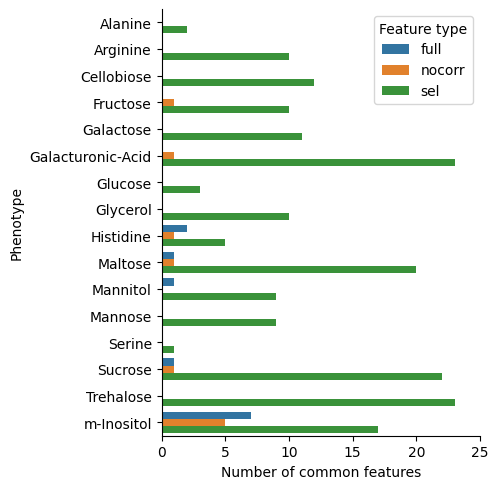

In [44]:
sns.catplot(data=common_features_dataset, y="phenotype", x="n_common_features", hue="ftype", kind="bar", orient="h", legend=False)
plt.xlim(0, N_FEATURES);
plt.xlabel("Number of common features");
plt.ylabel("Phenotype");
plt.legend(title="Feature type");
# plt.xticks(rotation=90);

### Are the common features across datasets related to the phenotype?

In [45]:
common_features_dataset["common_annots"] = common_features_dataset["common_features"].apply(lambda x: [ko_dict.get(k, k) for k in x])

In [46]:
def display_common_features(df, ftype, phenotype):
    common_annots = df[(df.ftype == ftype) & (df.phenotype == phenotype)]["common_annots"].values[0]
    return common_annots

In [47]:
# Galactose
display_common_features(common_features_dataset, "sel", "Galactose")

['galactonate dehydratase [EC:4.2.1.6]',
 'UDPglucose--hexose-1-phosphate uridylyltransferase [EC:2.7.7.12]',
 'GntR family transcriptional regulator, galactonate operon transcriptional repressor',
 'alpha-galactosidase [EC:3.2.1.22]',
 'UDP-N-acetyl-D-galactosamine dehydrogenase [EC:1.1.1.-]',
 'K23508',
 '2-dehydro-3-deoxygluconokinase [EC:2.7.1.45]',
 'LacI family transcriptional regulator',
 'monosaccharide-transporting ATPase [EC:3.6.3.17]',
 'beta-galactosidase [EC:3.2.1.23]',
 '2-dehydro-3-deoxyphosphogalactonate aldolase [EC:4.1.2.21]']

In [48]:
# Histidine
display_common_features(common_features_dataset, "sel", "Histidine")

['phosphoribosyl-AMP cyclohydrolase [EC:3.5.4.19]',
 'imidazolonepropionase [EC:3.5.2.7]',
 'urocanate hydratase [EC:4.2.1.49]',
 'GntR family transcriptional regulator, histidine utilization repressor',
 'imidazoleglycerol-phosphate dehydratase [EC:4.2.1.19]']

In [49]:
# Cellobiose
display_common_features(common_features_dataset, "sel", "Cellobiose")

['cellobiose transport system substrate-binding protein',
 'PTS system, cellobiose-specific IIC component',
 'cellobiose epimerase [EC:5.1.3.11]',
 'cellobiose transport system permease protein',
 'cellobiose phosphorylase [EC:2.4.1.20]',
 'cellobiose transport system permease protein',
 'PTS system, cellobiose-specific IIA component [EC:2.7.1.196 2.7.1.205]',
 'cellobionic acid phosphorylase [EC:2.4.1.321]',
 'PTS system, beta-glucoside (arbutin/salicin/cellobiose)-specific IIC component',
 'cellulose 1,4-beta-cellobiosidase [EC:3.2.1.91]',
 'PTS system, cellobiose-specific IIB component [EC:2.7.1.196 2.7.1.205]',
 'cellobiuronic acid synthase [EC:2.4.1.-]']

## Train on one dataset and predict on another

In [50]:
# Train on "atleaf" and test on "lit" and vice versa
combs = [("atleaf", "lit"), ("lit", "atleaf"), ("atleaf", "pmi"), ("lit", "pmi")]
indep_eval_scores = []
for ftype in ftypes:
    for phenotype_name in common_phenotype_names:
        for d1, d2 in combs:
            print(f"Processing {ftype}, {phenotype_name}, train:{d1}, test:{d2}")
            X_train = data_full[(ftype, d1, phenotype_name)]["X"]
            y_train = data_full[(ftype, d1, phenotype_name)]["y"]
            train_cols = X_train.columns
            X_test = data_full[("full", d2, phenotype_name)]["X"][train_cols]
            y_test = data_full[("full", d2, phenotype_name)]["y"]
            # randomly sample 70% of the test data
            for i in range(5):
                sampled_indices = np.random.choice(X_test.index, int(0.7 * len(X_test)), replace=False)
                X_test = X_test.loc[sampled_indices]
                y_test = y_test.loc[sampled_indices]
                nrows, ncols = X_train.shape
                if nrows < 50 or ncols < 5:
                    print(f"Skipping {ftype}, {phenotype_name} due to low data")
                    continue
                clf = make_classifier(CTYPE)
                clf.fit(X_train, y_train)
                y_pred = clf.predict(X_test)
                acc = accuracy_score(y_test, y_pred)
                bacc = balanced_accuracy_score(y_test, y_pred)
                mcc = matthews_corrcoef(y_test, y_pred)
                indep_eval_scores.append({
                    "ftype": ftype,
                    "phenotype": phenotype_name,
                    "train_dataset": d1,
                    "test_dataset": d2,
                    "sample": i+1,
                    "accuracy": acc,
                    "balanced_accuracy": bacc,
                    "mcc": mcc,
                })

Processing full, Alanine, train:atleaf, test:lit
Processing full, Alanine, train:lit, test:atleaf
Processing full, Alanine, train:atleaf, test:pmi
Processing full, Alanine, train:lit, test:pmi
Processing full, Arginine, train:atleaf, test:lit
Processing full, Arginine, train:lit, test:atleaf
Processing full, Arginine, train:atleaf, test:pmi
Processing full, Arginine, train:lit, test:pmi
Processing full, Cellobiose, train:atleaf, test:lit
Processing full, Cellobiose, train:lit, test:atleaf
Processing full, Cellobiose, train:atleaf, test:pmi
Processing full, Cellobiose, train:lit, test:pmi
Processing full, Fructose, train:atleaf, test:lit
Processing full, Fructose, train:lit, test:atleaf
Processing full, Fructose, train:atleaf, test:pmi
Processing full, Fructose, train:lit, test:pmi


/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:395: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:395: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Processing full, Galactose, train:atleaf, test:lit
Processing full, Galactose, train:lit, test:atleaf
Processing full, Galactose, train:atleaf, test:pmi


/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:395: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:395: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Processing full, Galactose, train:lit, test:pmi
Processing full, Galacturonic-Acid, train:atleaf, test:lit
Processing full, Galacturonic-Acid, train:lit, test:atleaf
Processing full, Galacturonic-Acid, train:atleaf, test:pmi
Processing full, Galacturonic-Acid, train:lit, test:pmi
Processing full, Glucose, train:atleaf, test:lit
Processing full, Glucose, train:lit, test:atleaf
Processing full, Glucose, train:atleaf, test:pmi


...

Processing sel, Mannitol, train:lit, test:pmi
Processing sel, Mannose, train:atleaf, test:lit
Processing sel, Mannose, train:lit, test:atleaf
Processing sel, Mannose, train:atleaf, test:pmi


/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2466: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2466: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:395: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:395: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, 

Processing sel, Mannose, train:lit, test:pmi


/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:395: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:395: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:395: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/sk

Processing sel, Serine, train:atleaf, test:lit
Processing sel, Serine, train:lit, test:atleaf
Processing sel, Serine, train:atleaf, test:pmi
Processing sel, Serine, train:lit, test:pmi
Processing sel, Sucrose, train:atleaf, test:lit
Processing sel, Sucrose, train:lit, test:atleaf
Processing sel, Sucrose, train:atleaf, test:pmi
Processing sel, Sucrose, train:lit, test:pmi
Processing sel, Trehalose, train:atleaf, test:lit
Processing sel, Trehalose, train:lit, test:atleaf
Processing sel, Trehalose, train:atleaf, test:pmi
Processing sel, Trehalose, train:lit, test:pmi
Processing sel, m-Inositol, train:atleaf, test:lit
Processing sel, m-Inositol, train:lit, test:atleaf
Processing sel, m-Inositol, train:atleaf, test:pmi
Processing sel, m-Inositol, train:lit, test:pmi


/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


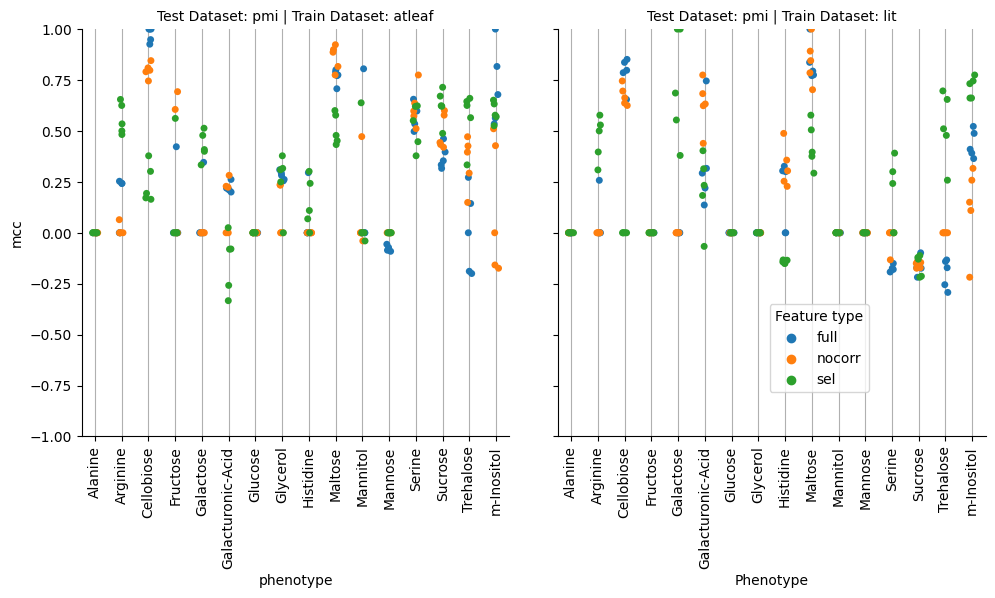

In [55]:
plot_data = pd.DataFrame(indep_eval_scores)
plot_data = plot_data[(plot_data.test_dataset == "pmi")]
g = sns.catplot(data=plot_data, x="phenotype", y="mcc", hue="ftype", kind="strip", row="test_dataset", col="train_dataset")
for ax in g.axes.flat:
    ax.set_ylim(-1, 1)
    ax.grid(True, axis="x")
    for label in ax.get_xticklabels():
        label.set_rotation(90)
plt.ylabel("MCC");
plt.xlabel("Phenotype");
g._legend.set_title("Feature type");
g._legend.set_bbox_to_anchor((0.8, 0.5))  # Center the legend at the bottom
g._legend.set_frame_on(True)
g.set_titles(row_template='Test Dataset: {row_name}', col_template='Train Dataset: {col_name}')

/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


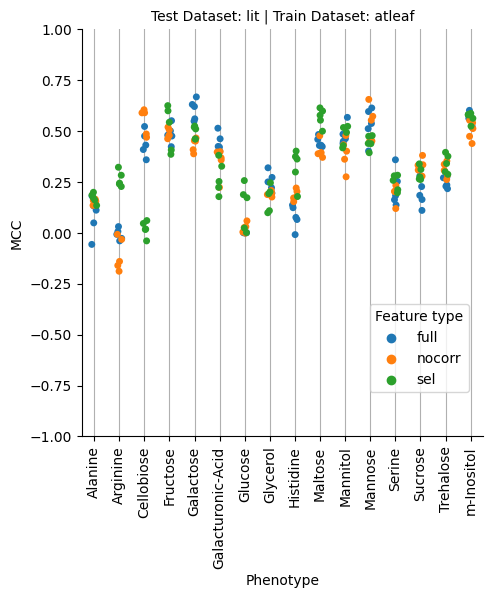

In [51]:
plot_data = pd.DataFrame(indep_eval_scores)
plot_data = plot_data[(plot_data.train_dataset == "atleaf") & (plot_data.test_dataset == "lit")]
g = sns.catplot(data=plot_data, x="phenotype", y="mcc", hue="ftype", kind="strip", row="test_dataset", col="train_dataset")
for ax in g.axes.flat:
    ax.set_ylim(-1, 1)
    ax.grid(True, axis="x")
    for label in ax.get_xticklabels():
        label.set_rotation(90)
plt.ylabel("MCC");
plt.xlabel("Phenotype");
g._legend.set_title("Feature type");
g._legend.set_bbox_to_anchor((0.8, 0.5))  # Center the legend at the bottom
g._legend.set_frame_on(True)
g.set_titles(row_template='Test Dataset: {row_name}', col_template='Train Dataset: {col_name}')

/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


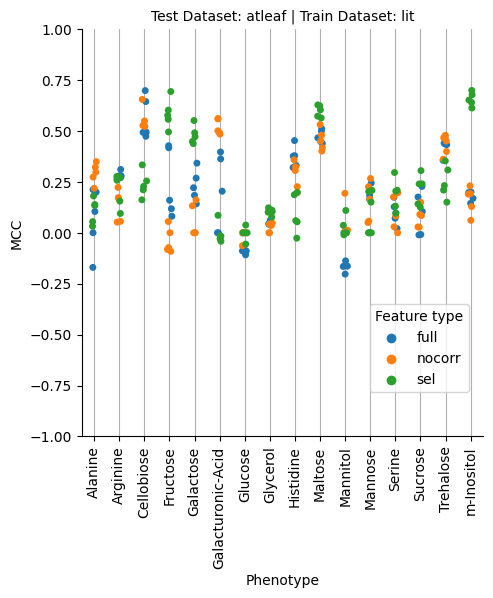

In [52]:
plot_data = pd.DataFrame(indep_eval_scores)
plot_data = plot_data[(plot_data.train_dataset == "lit") & (plot_data.test_dataset == "atleaf")]
g = sns.catplot(data=plot_data, x="phenotype", y="mcc", hue="ftype", kind="strip", row="test_dataset", col="train_dataset")
for ax in g.axes.flat:
    ax.set_ylim(-1, 1)
    ax.grid(True, axis="x")
    for label in ax.get_xticklabels():
        label.set_rotation(90)
plt.ylabel("MCC");
plt.xlabel("Phenotype");
g._legend.set_title("Feature type");
g._legend.set_bbox_to_anchor((0.8, 0.5))  # Center the legend at the bottom
g._legend.set_frame_on(True)
g.set_titles(row_template='Test Dataset: {row_name}', col_template='Train Dataset: {col_name}')

In [53]:
## Are the top features correlated to the selected features?

In [54]:
# For "Galactose" phenotype and "full" ftype, correlate the feature importance across the two datasets
common_features_galac_full = common_features_cv[(common_features_cv.ftype == "full") & (common_features_cv.phenotype == "Galactose")][["dataset", "common_features"]].set_index("dataset")
X_list = []
for dataset in DATASETS:
    flist = sorted(common_features_galac_full.loc[dataset].values[0])
    X = data_full[("full", "atleaf", "Galactose")]["X"][flist]
    X_list.append(X)

KeyError: 'pmi'

In [ ]:
correlation_results = pd.DataFrame(index=X_list[0].columns, columns=X_list[1].columns)
for col1 in X_list[0].columns:
    for col2 in X_list[1].columns:
        correlation_results.loc[col1, col2] = X_list[0][col1].corr(X_list[1][col2])

In [ ]:
correlation_results

In [ ]:
np.abs(correlation_results).max(axis=1)

### Are there common features among different phenotypes?

In [ ]:
common_features_dict = {}
for _, row in common_features_cv.iterrows():
    common_features_dict[(row.ftype, row.dataset, row.phenotype)] = row.common_features

In [ ]:
common_features_pairwise = {}
for ftype1, dataset1, phenotype1 in common_features_dict:
    id1 = f"{ftype1}_{dataset1}_{phenotype1}"
    for ftype2, dataset2, phenotype2 in common_features_dict:
        id2 = f"{ftype2}_{dataset2}_{phenotype2}"
        if id1 == id2:
            continue
        if phenotype1 == phenotype2:
            continue
        if ftype1 != ftype2:
            continue
        if dataset1 != dataset2:
            continue
        common_features1 = common_features_dict[(ftype1, dataset1, phenotype1)]
        common_features2 = common_features_dict[(ftype2, dataset2, phenotype2)]
        common_features_pairwise[f"{id1}-{id2}"] = common_features1.intersection(common_features2)

In [ ]:
common_features_pairwise_num_sorted = sorted({frozenset(k.split("-")): len(v) for k, v in common_features_pairwise.items()}.items(), key=lambda item: item[1], reverse=True)

In [ ]:
# top 10 pairs with most common features
for k, v in common_features_pairwise_num_sorted[:25]:
    ids = list(k)
    print(f"{ids[0]} and {ids[1]}: {v}")

In [ ]:
{k: ko_dict.get(k, "missing") for k in common_features_dict[("sel", "atleaf", "Fructose")]}